In [ ]:
"""3.1的最终完整代码"""

'3.1的最终完整代码'

原始数据量: 323598
去除疑似买粉后: 297031
readability 非空占比: 0.168
清洗后: 297031


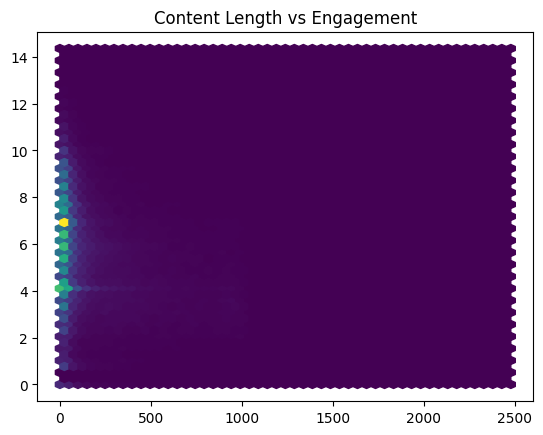

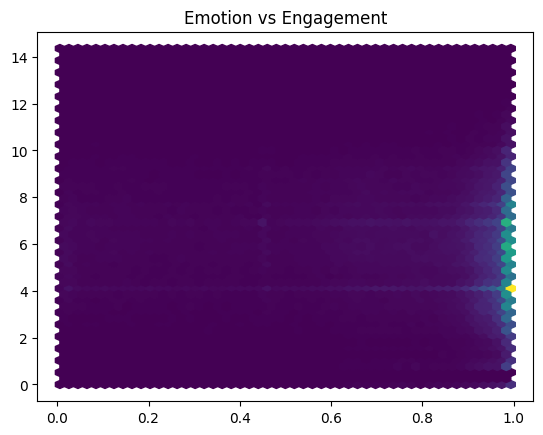

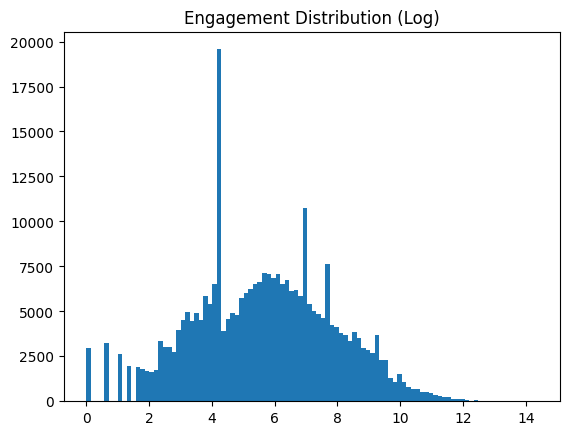

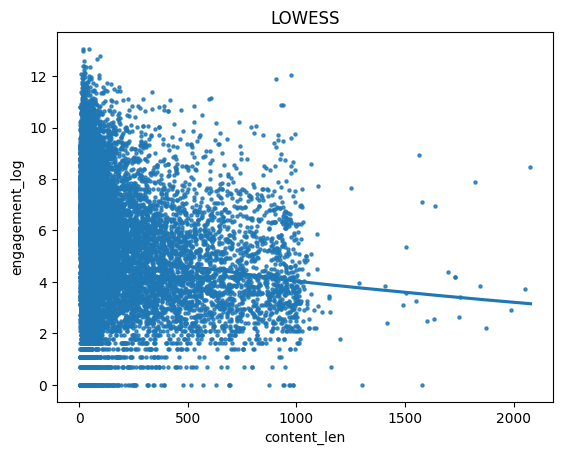

可用于建模的数据量: 49911
=== 主模型 ===
                            OLS Regression Results                            
Dep. Variable:         engagement_log   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     210.3
Date:                Thu, 23 Apr 2026   Prob (F-statistic):          2.61e-219
Time:                        23:06:33   Log-Likelihood:                -44302.
No. Observations:               20000   AIC:                         8.862e+04
Df Residuals:                   19994   BIC:                         8.866e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const      

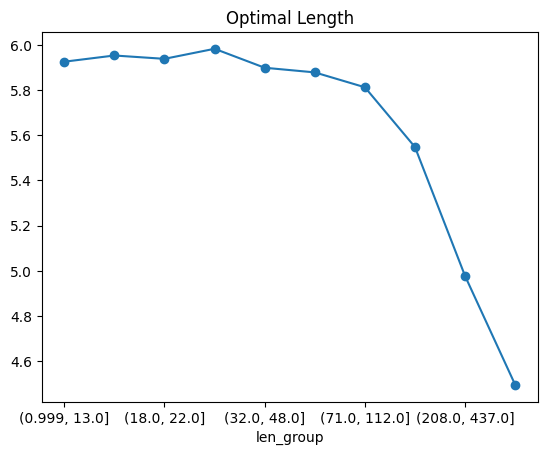

emotion_group
(0.00475, 0.613]    3446.398118
(0.613, 0.87]       3282.167792
(0.87, 0.955]       2548.065010
(0.955, 0.988]      2564.891507
(0.988, 0.994]      2619.826920
Name: engagement, dtype: float64
extreme_group
(-0.00099902, 0.235]    3588.926056
(0.235, 0.397]          3109.065298
(0.397, 0.459]          2590.136855
(0.459, 0.488]          2569.513896
(0.488, 0.494]          2603.675095
Name: engagement, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import jieba
import cntext

# ======================
# 1. 读取数据
# ======================
files = glob.glob("C:/Users/fire/all2/*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("原始数据量:", len(df))

# ======================
# 2. 基础清洗
# ======================
df["文本"] = df["文本"].astype(str)

df["likes"] = pd.to_numeric(df["相对准确点赞数"], errors="coerce")
df["comments"] = pd.to_numeric(df["相对准确评论数"], errors="coerce")
df["favs"] = pd.to_numeric(df["相对准确收藏数"], errors="coerce")
df["fans"] = pd.to_numeric(df["相对准确粉丝数"], errors="coerce")

df = df.dropna(subset=["likes", "comments", "favs"])

# ======================
# 3. 构建互动指标（核心）
# ======================
df["engagement"] = df["likes"] + df["favs"] + 4 * df["comments"]
df["engagement_log"] = np.log1p(df["engagement"])

# 互动率（用于买粉识别）
df["fans"] = df["fans"].replace(0, np.nan)
df["engagement_rate"] = df["engagement"] / df["fans"]

# ======================
# 4. 买粉过滤
# ======================
fan_threshold = df["fans"].quantile(0.9)
df = df[~(
    (df["fans"] > fan_threshold) &
    (df["engagement_rate"] < 0.01)
)]

print("去除疑似买粉后:", len(df))

# ======================
# 5. 文本特征
# ======================
df["title"] = df.get("文案（标题）", "").astype(str)
df["body"] = df.get("文案（正文）", "").astype(str)

df["title_len"] = df["title"].apply(len)
df["body_len"] = df["body"].apply(len)
df["content_len"] = df["文本"].apply(len)

# 分词（抽样）
def word_count(text):
    return len(jieba.lcut(text))

word_sample_n = min(20000, len(df))
sample_idx = df.sample(word_sample_n, random_state=42).index
df.loc[sample_idx, "word_count"] = df.loc[sample_idx, "文本"].apply(word_count)

# ======================
# 6. 可读性（cntext版）
# ======================
def get_readability(text):
    if not isinstance(text, str) or text.strip() == "":
        return np.nan

    try:
        r = cntext.readability(text, lang="chinese", return_series=False)

        if isinstance(r, dict):
            # 按你当前版本的常见返回键优先取值
            preferred_keys = [
                "fog_index",
                "flesch_kincaid_grade_level",
                "smog_index",
                "ari",
                "coleman_liau_index",
                "linsear_write_formula"
            ]
            for k in preferred_keys:
                if k in r and isinstance(r[k], (int, float, np.number)):
                    return float(r[k])

            # 兜底：取第一个数值字段
            for _, v in r.items():
                if isinstance(v, (int, float, np.number)):
                    return float(v)

        elif isinstance(r, (int, float, np.number)):
            return float(r)

        return np.nan
    except Exception:
        return np.nan

# 抽样计算可读性以控制耗时
read_sample_n = min(50000, len(df))
sample_idx = df.sample(read_sample_n, random_state=42).index
df.loc[sample_idx, "readability"] = df.loc[sample_idx, "文本"].apply(get_readability)

print("readability 非空占比:", round(df["readability"].notna().mean(), 4))

# ======================
# 7. 情感变量
# ======================
df["emotion_strength"] = pd.to_numeric(df["情感预测"], errors="coerce")
df["emotion_extreme"] = np.abs(df["emotion_strength"] - 0.5)

print("清洗后:", len(df))

# ======================
# 8. 可视化
# ======================
plt.hexbin(df["content_len"], df["engagement_log"], gridsize=50)
plt.title("Content Length vs Engagement")
plt.show()

plt.hexbin(df["emotion_strength"], df["engagement_log"], gridsize=50)
plt.title("Emotion vs Engagement")
plt.show()

plt.hist(df["engagement_log"], bins=100)
plt.title("Engagement Distribution (Log)")
plt.show()

# ======================
# 9. LOWESS（抽样）
# ======================
vis_n = min(20000, len(df))
df_sample = df.sample(vis_n, random_state=42)

sns.regplot(
    x=df_sample["content_len"],
    y=df_sample["engagement_log"],
    lowess=True,
    scatter_kws={"s": 5}
)
plt.title("LOWESS")
plt.show()

# ======================
# 10. OLS（主模型）
# ======================
df["content_len_sq"] = df["content_len"] ** 2

df_model = df.dropna(subset=[
    "engagement_log",
    "content_len",
    "content_len_sq",
    "emotion_strength",
    "emotion_extreme",
    "readability"
])

print("可用于建模的数据量:", len(df_model))
if len(df_model) < 1000:
    raise ValueError("可用数据太少，请检查 cntext 可读性接口是否生效")

model_n = min(20000, len(df_model))
df_sample = df_model.sample(n=model_n, random_state=42)

X = df_sample[[
    "content_len",
    "content_len_sq",
    "emotion_strength",
    "emotion_extreme",
    "readability"
]]
X = sm.add_constant(X)
y = df_sample["engagement_log"]

model = sm.OLS(y, X).fit()
print("=== 主模型 ===")
print(model.summary())

# ======================
# 11. 稳健性检验（去掉互动 top 1%）
# ======================
df_robust = df[df["engagement"] < df["engagement"].quantile(0.99)].copy()
df_robust["content_len_sq"] = df_robust["content_len"] ** 2

df_robust_model = df_robust.dropna(subset=[
    "engagement_log",
    "content_len",
    "content_len_sq",
    "emotion_strength",
    "emotion_extreme",
    "readability"
])

print("稳健性可建模数据量:", len(df_robust_model))
if len(df_robust_model) < 1000:
    raise ValueError("稳健性样本不足，请先检查可读性缺失")

robust_n = min(20000, len(df_robust_model))
df_robust_sample = df_robust_model.sample(n=robust_n, random_state=42)

X_r = df_robust_sample[[
    "content_len",
    "content_len_sq",
    "emotion_strength",
    "emotion_extreme",
    "readability"
]]
X_r = sm.add_constant(X_r)
y_r = df_robust_sample["engagement_log"]

model_r = sm.OLS(y_r, X_r).fit()
print("=== 稳健性检验模型 ===")
print(model_r.summary())

# ======================
# 12. 分组分析
# ======================
df["len_group"] = pd.qcut(df["content_len"], 10, duplicates="drop")
group = df.groupby("len_group", observed=True)["engagement_log"].mean()

group.plot(marker="o")
plt.title("Optimal Length")
plt.show()

# ======================
# 13. 情感分析
# ======================
df_emotion = df.dropna(subset=["emotion_strength", "emotion_extreme"]).copy()
df_emotion["emotion_group"] = pd.qcut(df_emotion["emotion_strength"], 5, duplicates="drop")
print(df_emotion.groupby("emotion_group", observed=True)["engagement"].mean())

df_emotion["extreme_group"] = pd.qcut(df_emotion["emotion_extreme"], 5, duplicates="drop")
print(df_emotion.groupby("extreme_group", observed=True)["engagement"].mean())